In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))  # Output layer with multiple neurons, one for each target variable
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=200, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Print the total number of training data points
print(f'Total Training Data Points: {X_train_scaled.shape[0]}')




Epoch 1/200

680/680 [==============================] - 7s 8ms/step - loss: 4243.9194 - val_loss: 4116.9819 - lr: 9.9287e-05
Epoch 2/200
680/680 [==============================] - 2s 3ms/step - loss: 3833.4634 - val_loss: 3402.3987 - lr: 9.8578e-05
Epoch 3/200
680/680 [==============================] - 2s 3ms/step - loss: 2982.1060 - val_loss: 2561.8491 - lr: 9.7875e-05
Epoch 4/200
680/680 [==============================] - 2s 3ms/step - loss: 2484.4636 - val_loss: 2306.1387 - lr: 9.7176e-05
Epoch 5/200
680/680 [==============================] - 2s 3ms/step - loss: 2371.4731 - val_loss: 2249.7065 - lr: 9.6482e-05
Epoch 6/200
680/680 [==============================] - 2s 3ms/step - loss: 2334.3098 - val_loss: 2220.0771 - lr: 9.5793e-05
Epoch 7/200
680/680 [==============================] - 2s 3ms/step - loss: 2305.6440 - val_loss: 2199.0398 - lr: 9.5110e-05
Epoch 8/200
680/680 [==============================] - 2s 3ms/step - loss: 2287.6184 - val_loss: 2183.7312 - lr: 9.4431e-05
Epoch

31/31 [==============================] - 0s 2ms/step


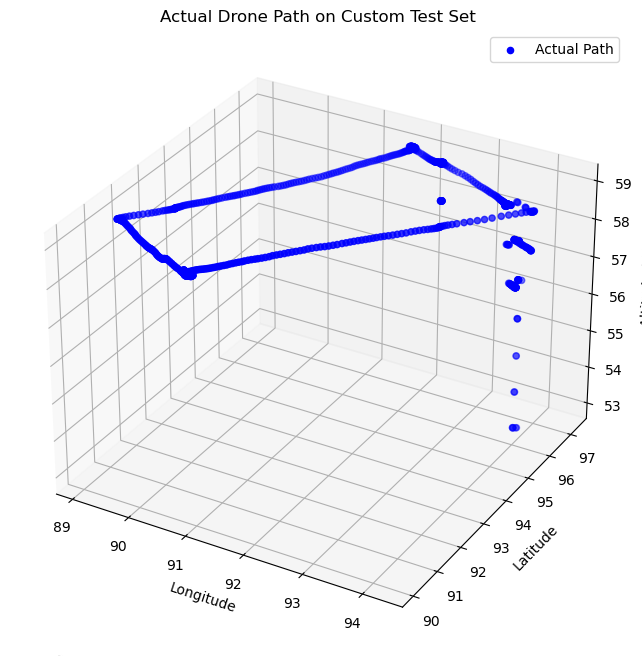

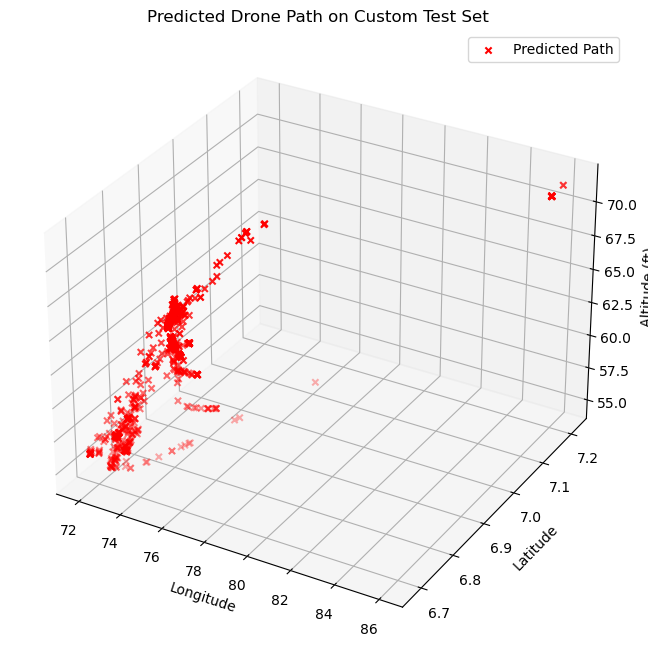

34005


In [2]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print( X_train_scaled.shape[0])


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Reshape data for CNN
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Build a CNN model without pooling layers
model = keras.Sequential([
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))  # Output layer with multiple neurons, one for each target variable
])



# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_reshaped, y_train, epochs=200, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Evaluate the model on the test set
y_pred = model.predict(X_test_reshaped)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Print the total number of training data points
print(f'Total Training Data Points: {X_train_reshaped.shape[0]}')




Epoch 1/200

426/426 [==============================] - 4s 5ms/step - loss: 4760.8120 - val_loss: 4146.5254 - lr: 9.9553e-05
Epoch 2/200
426/426 [==============================] - 2s 5ms/step - loss: 3363.7163 - val_loss: 2874.5100 - lr: 9.9107e-05
Epoch 3/200
426/426 [==============================] - 2s 4ms/step - loss: 2919.0391 - val_loss: 2726.2324 - lr: 9.8664e-05
Epoch 4/200
426/426 [==============================] - 2s 4ms/step - loss: 2819.4771 - val_loss: 2657.4246 - lr: 9.8222e-05
Epoch 5/200
426/426 [==============================] - 2s 5ms/step - loss: 2757.5928 - val_loss: 2626.9705 - lr: 9.7782e-05
Epoch 6/200
426/426 [==============================] - 2s 4ms/step - loss: 2724.1716 - val_loss: 2607.0771 - lr: 9.7344e-05
Epoch 7/200
426/426 [==============================] - 2s 5ms/step - loss: 2708.3726 - val_loss: 2597.7771 - lr: 9.6908e-05
Epoch 8/200
426/426 [==============================] - 2s 5ms/step - loss: 2694.5503 - val_loss: 2589.4407 - lr: 9.6474e-05
Epoch

426/426 [==============================] - 2s 5ms/step - loss: 2390.1965 - val_loss: 2299.2698 - lr: 5.6806e-05
Epoch 127/200
426/426 [==============================] - 2s 5ms/step - loss: 2391.8772 - val_loss: 2296.6707 - lr: 5.6552e-05
Epoch 128/200
426/426 [==============================] - 2s 4ms/step - loss: 2389.5913 - val_loss: 2296.1812 - lr: 5.6299e-05
Epoch 129/200
426/426 [==============================] - 2s 4ms/step - loss: 2387.2708 - val_loss: 2293.5437 - lr: 5.6047e-05
Epoch 130/200
426/426 [==============================] - 2s 4ms/step - loss: 2386.6902 - val_loss: 2291.8774 - lr: 5.5796e-05
Epoch 131/200
426/426 [==============================] - 2s 5ms/step - loss: 2391.9363 - val_loss: 2291.3220 - lr: 5.5546e-05
Epoch 132/200
426/426 [==============================] - 2s 4ms/step - loss: 2385.0420 - val_loss: 2288.3362 - lr: 5.5297e-05
Epoch 133/200
426/426 [==============================] - 3s 6ms/step - loss: 2379.4146 - val_loss: 2287.0649 - lr: 5.5049e-05
Epoch 

In [ ]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print( X_train_scaled.shape[0])


# new

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.base import BaseEstimator, RegressorMixin

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df_train[input_features]
y = df_train[output_targets]

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Define a wrapper class for KerasRegressor
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001, epochs=100, batch_size=32):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def create_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.neurons, activation='relu', input_shape=(X_train.shape[1],)))
        model.add(layers.Dropout(self.dropout_rate))
        for _ in range(self.layers - 1):
            model.add(layers.Dense(self.neurons, activation='relu'))
            model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(len(output_targets)))
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Define hyperparameters to tune
param_grid = {
    'layers': [1, 2, 3], # number of hidden layers
    'neurons': [32, 64, 128], # number of neurons per layer
    'dropout_rate': [0.3, 0.5], # dropout rate
    'learning_rate': [0.001, 0.0001], # learning rate
    'epochs': [50, 100], # number of training epochs
    'batch_size': [32, 64] # batch size
}

# Create KerasRegressor wrapper
model = KerasRegressorWrapper()

# Perform grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3)
grid_result = grid.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", grid_result.best_params_)
print("Best Score:", grid_result.best_score_)

# Extract results from grid search
results = pd.DataFrame(grid_result.cv_results_)

# Define hyperparameters to plot
hyperparameters = ['param_layers', 'param_neurons', 'param_dropout_rate', 'param_learning_rate',
                   'param_epochs', 'param_batch_size']

# Plot grid search results
plt.figure(figsize=(12, 12))
for i, param in enumerate(hyperparameters):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=param, y='mean_test_score', data=results, ax=plt.gca())
    plt.title(f'Grid Search CV - {param}')
    plt.xlabel(param)
    plt.ylabel('Mean Test Score')
plt.tight_layout()
plt.show()




355/355 [==============================] - 1s 2ms/step


KeyboardInterrupt: 

In [2]:
pip install tensorflow-gpu

Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [44 lines of output]
  Traceback (most recent call last):
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\requirements.py", line 35, in __init__
      parsed = _parse_requirement(requirement_string)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 64, in parse_requirement
      return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 82, in _parse_requirement
      url, specifier, marker = _parse_requirement_details(tokenizer)
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_v

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


In [8]:
# Import necessary libraries
import tensorflow as tf

# Check if GPU is available
if tf.test.gpu_device_name():
    print('GPU is available')
else:
    print("GPU not found. Running on CPU.")

# Specify GPU device
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Specify which GPU to use, if you have multiple

# Ensure TensorFlow uses GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)  # Set memory growth to avoid OOM errors
    print('TensorFlow is using GPU')
else:
    print("GPU not found. TensorFlow is using CPU.")


GPU not found. Running on CPU.
GPU not found. TensorFlow is using CPU.


In [1]:
pip install --user tensorflow-gpu


  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [44 lines of output]
  Traceback (most recent call last):
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\requirements.py", line 35, in __init__
      parsed = _parse_requirement(requirement_string)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 64, in parse_requirement
      return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 82, in _parse_requirement
      url, specifier, marker = _parse_requirement_details(tokenizer)
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\ProgramData\anaconda3\Lib\site-packages\setuptools\_v